# Construire un modèle GSM pour un problème élastoplastique et faire son identification sur les données précédentes

In [2]:
import jax
jax.config.update("jax_platform_name","cpu")
jax.config.update("jax_enable_x64", True)


In [3]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxmat
import jaxmat.materials as jm
from jaxmat.loader import ImposedLoading, global_solve,solver, adjoint, residual
from jaxmat.tensors import SymmetricTensor2, dev, main_invariants
from sklearn.metrics import r2_score
from jaxmat.utils import partition_by_node_names
import numpy as np
from jaxmat.state import AbstractState, make_batched
import optax
import optimistix as optx
from jaxmat.nn.icnn import HomogeneousICNN, ICNN     
from optax.tree_utils import tree_scale, tree_sub

## I. Construction des données "expérimentales"

/tmp/ipykernel_862505/1059361217.py:22: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  material = jm.vonMisesIsotropicHardeni

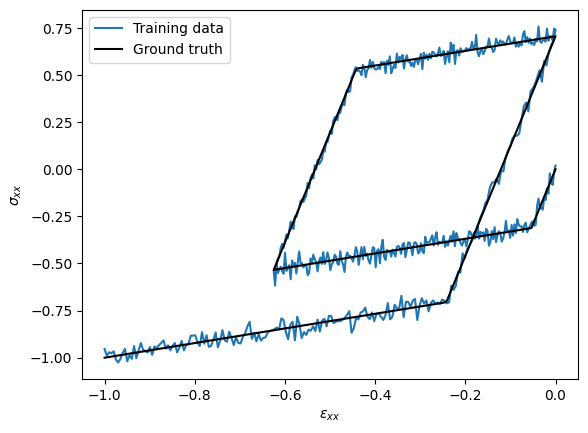

E=5.826499784203139


In [4]:
class LinearHardening(eqx.Module):
    sig0: jax.Array = eqx.field(converter=lambda x: jnp.asarray(x, dtype=jnp.float64))  # Limite d'élasticité (MPa)
    H: jax.Array = eqx.field(converter=lambda x: jnp.asarray(x, dtype=jnp.float64))      # Module d'écrouissage (MPa)
    
    def __call__(self, p):
        return self.sig0 + self.H * p

Nsteps = 200
sec1 = jnp.linspace(0, -0.05, Nsteps)   # 1ere charge en compression
sec2 = jnp.linspace(-0.05, 0, Nsteps)   # 1ere décharge
sec3 = jnp.linspace(0, -0.08, Nsteps)   # 2nd charge en compression

imposed_eps_path = jnp.concatenate([sec1, sec2[1:] ,sec3[1:]])
E=70e3
nu=0.33
sig0=300
H=5e3


elasticity = jm.LinearElasticIsotropic(E=E, nu=nu)
hardening = LinearHardening(sig0=sig0, H=H)
material = jm.vonMisesIsotropicHardening(elasticity=elasticity, yield_stress=hardening)

dt = 1  # indépendant du temps

@eqx.filter_jit
def simulate(material, eps_path):
    state0 = material.init_state(Nbatch=1)
    Eps0 = state0.strain

    def step(carry, imposed_eps):
        Eps, state = carry
        loading = ImposedLoading(epsxx=imposed_eps, sigyy=0.0, sigzz=0.0)
        Eps, state, stats = global_solve(Eps, state, loading, material, dt)
        # On renvoie les tenseurs complets (3x3), plus l'état interne si besoin
        return (Eps, state), (Eps.tensor, state.stress.tensor)

    (_, _), (eps_hist, sig_hist) = jax.lax.scan(step, (Eps0, state0), eps_path)
    return eps_hist, sig_hist

eps_tensor_hist_, sig_tensor_hist_ = simulate(material, imposed_eps_path)

eps_max = jnp.max(jnp.abs(eps_tensor_hist_))
sig_max = jnp.max(jnp.abs(sig_tensor_hist_))
E_max= sig_max/eps_max


eps_tensor_hist = eps_tensor_hist_/eps_max
sig_tensor_hist = sig_tensor_hist_/sig_max
# eps_tensor_hist, sig_tensor_hist ont la forme (Nsteps_total, Nbatch, 3, 3)

eps_xx = eps_tensor_hist[:, 0, 0, 0]
sig_xx = sig_tensor_hist[:, 0, 0, 0]


key = jax.random.key(42)
key1, key2 = jax.random.split(key)

noise_level = 0.03

# Bruit appliqué composante par composante sur le tenseur sigxx
sig_noise = noise_level * jnp.max(jnp.abs(sig_xx)) * jax.random.normal(key2, shape=sig_xx.shape)
sigxx_noise= np.zeros((598, 1, 3, 3))
sigxx_noise[:,0,0,0]= sig_noise

eps_exp = eps_tensor_hist             
sig_exp = (sig_tensor_hist + sigxx_noise)

plt.figure()
plt.plot(eps_exp[:,0,0,0],sig_exp[:,0,0,0],label="Training data")
plt.plot(eps_xx,sig_xx,"-k",label="Ground truth")
plt.xlabel(r"$\epsilon_{xx}$")
plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.show()

print(f"E={E/E_max}")

## II. Variables internes

In [5]:
class InternalState(AbstractState):
    eps_p: SymmetricTensor2 = eqx.field(default=None) # Déformation plastique
    p: jax.Array = eqx.field(default=None) # Déformation plastique équivalente cumulée (variable d'écrouissage)

    def __post_init__(self):  # définition à posteriori sinon nulle
        if self.eps_p is None:
            object.__setattr__(self, "eps_p", SymmetricTensor2())
        if self.p is None:
            object.__setattr__(self, "p", jnp.zeros(()))

## III. L'énergie libre $\psi$

L'énergie libre de Helmotz dans le cas élastoplastique se décompose en une partie élastique et une partie écrouissage : 

$\psi(\epsilon,\epsilon_p,p)= \frac{1}{2} (\epsilon - \epsilon_p ): \mathbb{C} : (\epsilon - \epsilon_p ) + \frac{1}{2}Hp² ~$ ou $~\psi(\epsilon,\epsilon_p,p)= \frac{1}{2} (\epsilon - \epsilon_p ): \mathbb{C} : (\epsilon - \epsilon_p ) + N_{ICNN}(p) $

In [6]:
class FreeEnergy(eqx.Module):
    elasticity: jm.AbstractLinearElastic  # Hooke isotrope
    # nn_anelastic: ICNN  # ICNN for eps_p variable
    nn_hardening: ICNN  # ICNN for p variable

    def __call__(self, eps, isv):
        eps_p = isv.eps_p
        psi_elastic = self.elasticity.strain_energy(eps - eps_p)

        _, I2, _ = main_invariants(isv.eps_p)
        #psi_anelastic = self.nn_anelastic(I2)
        psi_hardening = self.nn_hardening(isv.p)
        f0, linear_term = jax.jvp(self.nn_hardening,
                    (jnp.zeros_like(isv.p),),
                    (isv.p,),)
                
        # énergie totale
        return psi_elastic + psi_hardening - f0 - linear_term#+ psi_anelastic

## IV. Le potentiel de dissipation dual $\phi*$

On défini : $Φ{(\dot\epsilon_p,\dot p​)} = N_{ICNN​}(q,\dot p) ~~$ avec $ q=tr(dev(\dot\epsilon_p))  $

In [ ]:
from optax.tree_utils import tree_zeros_like, tree_vdot

from jaxmat.tensors import SymmetricTensor2, dev, eigenvalues
from jaxmat.tensors.utils import safe_norm, safe_sqrt
class ICNNDissipationPotential(ICNN):
    def icnn_potential(self, A, Q=None):
        """
        A : SymmetricTensor2 (batch Nvar, 3,3)
        Q : jnp.ndarray (batch Nvar,) ou None
        """
        # Calcul invariants principaux du batch de A
        # I1, I2, I3 = main_invariants(A) 
        J2 = jnp.sqrt(3 / 2.0) * safe_norm(A - SymmetricTensor2.identity() * (jnp.trace(jnp.asarray(A)) / 3))
        # Construit l'entrée du réseau
        if Q is not None:
            J2 = jnp.atleast_1d(J2)
            Q  = jnp.atleast_1d(Q)
            x = jnp.concatenate([J2, Q])
        else:
            x = J2
        return super().__call__(x)

    def __call__(self, isv):
        """
        isv: objet avec
            .A : SymmetricTensor2 (forces sur alpha_p)
            .Q : jnp.ndarray (forces sur q)
        """
        A_p = isv.eps_p.tensor       
        Q = isv.p       

        # Potentiel pseudo-dissipatif dual
        f0, linear_term1 = jax.jvp(
            lambda a: self.icnn_potential(SymmetricTensor2(tensor=a), jnp.zeros_like(Q)),
            (jnp.zeros_like(A_p),),
            (A_p,),
        )
        f0, linear_term2 = jax.jvp(
                    lambda q: self.icnn_potential(SymmetricTensor2(tensor=jnp.zeros_like(A_p)), q),
                    (jnp.zeros_like(Q),),
                    (Q,),
                )
        return self.icnn_potential(A_p, Q) - f0 - linear_term1 - linear_term2


## V. Assemblage et compilation

In [8]:
from abc import abstractmethod
import jaxmat.materials as jm
import equinox as eqx
import lineax as lx
from jaxmat.solvers import NewtonTrustRegion
from optax.tree_utils import tree_add, tree_zeros_like, tree_scale, tree_sub
import jax
import optimistix as optx

class GeneralizedStandardMaterialDual(jm.SmallStrainBehavior):
    r"""
    GSM where internal variables evolve by solving the implicit equation with an optax solver.

    dot(alpha) = dPhi_star_dA( A_dis ), with A_dis = - dPsi/dalpha

    Attributes:
        free_energy: eqx.Module, Psi(eps, alpha) -> scalar or tensor
        dual_dissipation: eqx.Module, Phi^*(A_dis) -> scalar (or differentiable scalar-like)
    """

    free_energy: eqx.Module
    r"""Module defining the Helmholtz free energy $\Psi(\beps,\balpha)"""
    dual_dissipation_potential: eqx.Module
    r"""Module defining the dual dissipation pseudo-potential $Phi^*(A_dis)$"""
    minimisation_solver = NewtonTrustRegion(
        rtol=1e-6, atol=1e-6, linear_solver=lx.AutoLinearSolver(well_posed=False)
    )

    @abstractmethod
    def make_internal_state(self):
        """Create internal state variables."""
        pass

    def residual(self, d_isv, args):
        r"""
        Residual of the implicit evolution equation for internal variables.

        Parameters
        ----------
        d_isv : PyTree
            Increment of internal variables Delta alpha.
        args : tuple
            (eps, state, dt)
        """
        eps, state, dt = args
        isv_old = state.internal
        isv = tree_add(isv_old, d_isv)  # alpha_{n+1}
        isv_dot = tree_scale(1.0 / dt, d_isv)

        # Dissipative force A_dis = - dPsi / dalpha
        A_dis = jax.jacfwd(self.free_energy, argnums=1)(eps, isv)
        A_dis = tree_scale(-1, A_dis)

        # Flow rule: dot(alpha) - dPhi*(A_dis) = 0
        flow = jax.grad(self.dual_dissipation_potential)(A_dis)

        return tree_sub(isv_dot, flow)

    def constitutive_update(self, eps, state, dt):
        isv_old = state.internal
        d_isv0 = tree_zeros_like(isv_old)
        args = eps, state, dt

        sol = optx.root_find(
            self.residual,
            solver=self.minimisation_solver,
            y0=d_isv0,
            args=args,
            throw=False,
        )

        d_isv = sol.value
        isv = tree_add(isv_old, d_isv)

        # Stress: sigma = dPsi / deps
        sig = jax.jacfwd(self.free_energy, argnums=0)(eps, isv)

        new_state = state.update(stress=sig, internal=isv)
        return sig, new_state

In [9]:
hidden_dims_hard = [8,8] # (16,16,16)
Nvar = 1
key = jax.random.PRNGKey(42)
key1, key2, key3 = jax.random.split(key, num=3)  # define keys for reproducibility
W_SHIFT = -4.0


nn_hardening_init = ICNN(1, hidden_dims_hard, key2)
# nn_hardening_init = eqx.tree_at(lambda m: m.Ws, nn_hardening_init, [W + W_SHIFT for W in nn_hardening_init.Ws])
# nn_hardening_init = eqx.tree_at(lambda m: m.final_W, nn_hardening_init, nn_hardening_init.final_W + W_SHIFT)

# nn_anelastic = ICNN(1, hidden_dims, key1)  # one input the second main invariant

k_elastic = 18
_exx_elastic = np.asarray(eps_exp[:k_elastic, 0, 0, 0])
_sxx_elastic = np.asarray(sig_exp[:k_elastic, 0, 0, 0])
_E_slope, _ = np.polyfit(_exx_elastic, _sxx_elastic, 1)
E_init_guess = float(_E_slope)
print(f"E identifie separement (segment elastique) = {E_init_guess * E_max:.2f} MPa "
      f"(normalise = {E_init_guess:.4f})")

elasticity_init = jm.LinearElasticIsotropic(E=E_init_guess, nu=0.33)


free_energy=FreeEnergy(elasticity=elasticity_init,nn_hardening=nn_hardening_init  ) #,nn_anelastic=nn_anelastic) 

psi_init = free_energy

hidden_dims = [8,8]

icnn_dissip = ICNNDissipationPotential(Nvar + 1, hidden_dims, key3)

class GSM(GeneralizedStandardMaterialDual):
    def make_internal_state(self):
        return InternalState()

material_gsm_dual_init = GSM(free_energy=psi_init, dual_dissipation_potential=icnn_dissip)


E identifie separement (segment elastique) = 66498.08 MPa (normalise = 5.5350)


/tmp/ipykernel_862505/2534704630.py:37: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  material_gsm_dual_init = GSM(free_ener

In [10]:
state = material_gsm_dual_init.init_state()

# print(jax.grad(material_gsm_dual_init.free_energy, argnums=0)(state.eps,state.internal).tensor)
# print(jax.grad(material_gsm_dual_init.free_energy, argnums=1)(state.eps,state.internal).eps_p.tensor)
# print(jax.grad(material_gsm_dual_init.free_energy, argnums=1)(state.eps,state.internal).p)

# print(jax.grad(material_gsm_dual_init.dual_dissipation_potential)(state.internal).eps_p.tensor)
# print(material_gsm_dual_init.dual_dissipation_potential(state.internal))
# print(jax.grad(material_gsm_dual_init.dual_dissipation_potential)(state.internal).p)
# print(jax.grad(material_gsm_dual_init.dual_dissipation_potential)(state.internal).eps_p.tensor)
# print(material_gsm_dual_init.dual_dissipation_potential(state.internal))


### Vérifications avant tout entraînement

1. $\Phi^*(0) = 0$
2. $\nabla_A \Phi^*(0) = 0$ — traduction physique : à force duale nulle, la vitesse des variables internes prédite par la forme duale de l'équation de Biot ($\dot\alpha=\nabla_A\Phi^*$) est nulle, donc le matériau reste élastique tant qu'aucune force motrice ne s'exerce.
3. **Convexité de $\Phi^*$** (test de Jensen sur des couples aléatoires de $A_{dis}$)

In [11]:
def check_thermo_consistency(phi_star, label, N_test=500, seed=0):
    """Verifie Phi*(0)=0, grad Phi*(0)=0, et la convexite de Phi* (test de Jensen)."""
    zero_isv = InternalState()
    phi0, grad0_flow = jax.value_and_grad(phi_star)(zero_isv)
    max_grad0 = float(jnp.abs(grad0_flow.eps_p.tensor).max()) + float(jnp.abs(grad0_flow.p))

    print(f"--- Verification thermodynamique ({label}) ---")
    print(f"Phi*(0)           = {float(phi0):.3e}   (attendu : 0)")
    print(f"max|grad Phi*(0)| = {max_grad0:.3e}   (attendu : 0)")

    def random_A(key):
        k1, k2, k4 = jax.random.split(key, 3)
        M = jax.random.normal(k1, (3, 3))
        M = 0.5 * (M + M.T)
        scale = jax.random.uniform(k4, (), minval=0.1, maxval=5.0)
        return InternalState(eps_p=SymmetricTensor2(tensor=scale * M), p=scale * jax.random.normal(k2, ()))

    def tree_lerp(t, a, b):
        def _lerp(x, y):
            tt = t.reshape((-1,) + (1,) * (x.ndim - 1))
            return tt * x + (1 - tt) * y
        return jax.tree_util.tree_map(_lerp, a, b)

    key_test = jax.random.key(seed)
    k_A1, k_A2, k_t = jax.random.split(key_test, 3)
    A1 = jax.vmap(random_A)(jax.random.split(k_A1, N_test))
    A2 = jax.vmap(random_A)(jax.random.split(k_A2, N_test))
    t = jax.random.uniform(k_t, (N_test,), minval=0.05, maxval=0.95)
    A_mid = tree_lerp(t, A1, A2)

    phi1 = jax.vmap(phi_star)(A1)
    phi2 = jax.vmap(phi_star)(A2)
    phi_mid = jax.vmap(phi_star)(A_mid)

    jensen_gap = t * phi1 + (1 - t) * phi2 - phi_mid   # doit rester >= 0 si Phi* convexe
    n_violations = int(jnp.sum(jensen_gap < -1e-8))
    print(f"Test de convexite (Jensen, {N_test} couples aleatoires) : {n_violations} violation(s)   (attendu : 0)")
    print(f"min(t*Phi1+(1-t)*Phi2 - Phi_mid) = {float(jensen_gap.min()):.3e}   (doit rester >= 0)\n")

    return phi0, max_grad0, n_violations


check_thermo_consistency(material_gsm_dual_init.dual_dissipation_potential, "avant entrainement")


--- Verification thermodynamique (avant entrainement) ---
Phi*(0)           = 0.000e+00   (attendu : 0)
max|grad Phi*(0)| = 0.000e+00   (attendu : 0)
Test de convexite (Jensen, 500 couples aleatoires) : 0 violation(s)   (attendu : 0)
min(t*Phi1+(1-t)*Phi2 - Phi_mid) = 2.675e-01   (doit rester >= 0)



(Array(0., dtype=float64), 0.0, 0)

Le solveur de Imposedloading ne fonctionnant pas on veut quand même imposer epsxx et sigyy=sigzz=0 or cela n'est pas possible directement avec constitutive_update. On impose donc epsyy et epszz de sorte à ce que sigyy=sigzz=0. La fonction solve_lateral sert précisement àtrouver ces eps.

In [12]:
import jax.flatten_util  # requis par l1reg 
epsxx_exp = eps_exp[:, 0, 0, 0]
sigxx_exp = sig_exp[:, 0, 0, 0]

def build_eps(exx, el):
    z = jnp.zeros_like(exx)
    return SymmetricTensor2(tensor=jnp.array([[exx, z, z], [z, el, z], [z, z, el]]))


def solve_lateral(material, state, exx, dt=1.0,y0=None):
    def sig_yy(el, _):
        sig, _ = material.constitutive_update(build_eps(exx, el), state, dt)
        return sig.tensor[1, 1]
    y0 = -0.33 * exx if y0 is None else y0          # valeur par défaut au 1er pas
    sol = optx.root_find(
        sig_yy, optx.Newton(rtol=1e-8, atol=1e-8,
        linear_solver=lx.AutoLinearSolver(well_posed=False)),
        y0, throw=False,
    )
    return sol.value


In [13]:
def _compute_evolution(material, epsxx_path, dt=1.0):
    state0 = material.init_state()
    el_prev0 = -0.33 * epsxx_path[0]
    def step(carry, exx):
        state, el_prev = carry
        el = solve_lateral(material, state, exx, dt,y0=el_prev)
        new_stress, new_state = material.constitutive_update(build_eps(exx, el), state, dt)
        return (new_state, el), new_stress.tensor[0, 0]
    _, sig_xx = jax.lax.scan(step, (state0,el_prev0), epsxx_path)
    return sig_xx

def _compute_state(material, epsxx_path, dt=1.0):
    state0 = material.init_state()
    el_prev0 = -0.33 * epsxx_path[0]
    def step(carry, exx):
        state, el_prev = carry
        el = solve_lateral(material, state, exx, dt,y0=el_prev)
        new_stress, new_state = material.constitutive_update(build_eps(exx, el), state, dt)
        new_state = new_state.update(strain=build_eps(exx, el))
        return (new_state, el), new_state


    _, state = jax.lax.scan(step, (state0,el_prev0), epsxx_path)
    return state

compute_evolution = eqx.filter_jit(_compute_evolution)
batched_compute_evolution = eqx.filter_jit(jax.vmap(_compute_evolution, in_axes=(None, 0, None)))

compute_state = eqx.filter_jit(_compute_state)
batched_compute_state = eqx.filter_jit(jax.vmap(_compute_state, in_axes=(None, 0, None)))


Prédiction intiale :

In [15]:
import time

t0 = time.time()
sig_init = compute_evolution(material_gsm_dual_init, eps_xx)
sig_init.block_until_ready()
print("(compile + exec):", time.time() - t0)



EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/tmp/ipykernel_862505/3387929088.py", line 9, in _compute_evolution
    _, sig_xx = jax.lax.scan(step, (state0,el_prev0), epsxx_path)
  File "/tmp/ipykernel_862505/3387929088.py", line 6, in step
    el = solve_lateral(material, state, exx, dt,y0=el_prev)
  File "/tmp/ipykernel_862505/765047586.py", line 15, in solve_lateral
    sol = optx.root_find(
  File "/home/md266594/.venvs/pt2mfront/lib/python3.10/site-packages/optimistix/_root_find.py", line 218, in root_find
    return iterative_solve(
  File "/home/md266594/.venvs/pt2mfront/lib/python3.10/site-packages/optimistix/_iterate.py", line 344, in iterative_solve
    ) = adjoint.apply(_iterate, rewrite_fn, inputs, tags)
  File "/home/md266594/.venvs/pt2mfront/lib/python3.10/site-packages/equinox/_module/_prebuilt.py", line 33, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
  File "/home/md266594/.venvs/pt2mfront/lib

In [14]:

plt.figure()
# plt.plot(epsxx_exp, sigxx_exp, label="Training data")
# plt.plot(eps_xx, sig_xx, "-k", label="Ground truth")
plt.plot(eps_xx, sig_init, label="Materiau initial (dual)")
plt.xlabel(r"$\epsilon_{xx}$")
plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.show()

NameError: name 'sig_init' is not defined

<Figure size 640x480 with 0 Axes>

In [56]:
state = compute_state(material_gsm_dual_init, eps_xx)

In [57]:
state.internal.eps_p

SymmetricTensor2(shape=(598, 6))

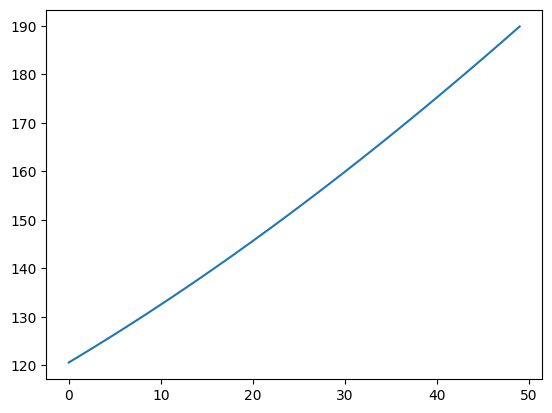

In [80]:
x = jnp.linspace(0,1)
plt.plot(jax.vmap(material_gsm_dual_init.free_energy.nn_hardening)(x))

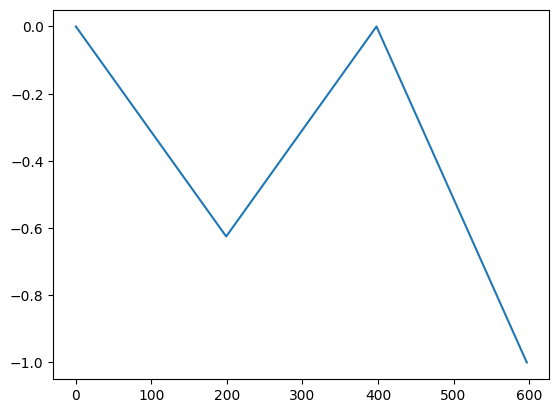

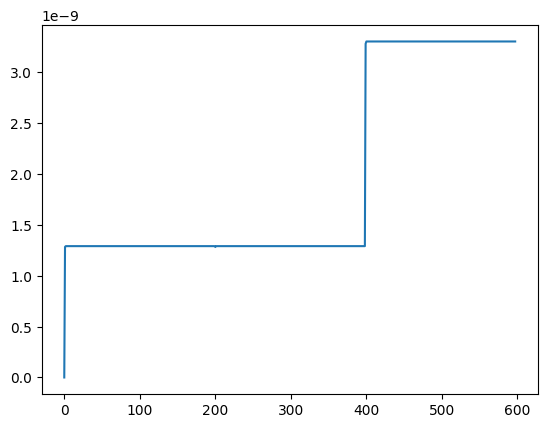

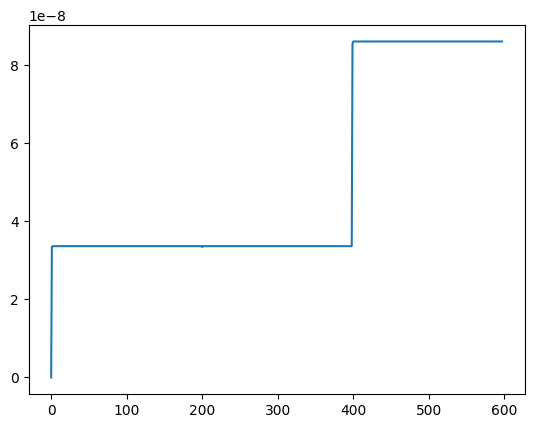

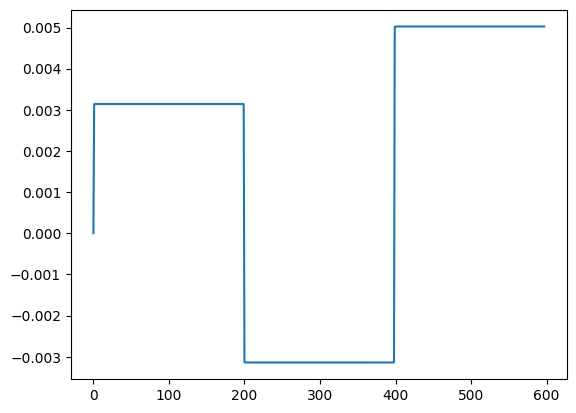

In [77]:
plt.figure()
# # plt.plot(state.internal.eps_p[:,0,0])
# # plt.plot(state.sig[:,0,0])
# # plt.plot(state.internal.eps_p[:,0,0])
plt.plot(eps_xx)
# plt.plot(state.internal.p)
# # plt.plot(state.eps[:,0,0])
# # plt.plot((eps_xx - state.internal.eps_p[:,0,0]) * E/E_max)#)/(1 - nu))
# # plt.plot(state.)
plt.show()

plt.figure()
plt.plot(jax.vmap(jax.grad(material_gsm_dual_init.free_energy, argnums=1))(state.eps, state.internal).p)
plt.show()

flux = jax.vmap(jax.grad(material_gsm_dual_init.free_energy, argnums=1))(state.eps, state.internal)
plt.figure()
plt.plot(jax.vmap(jax.grad(material_gsm_dual_init.dual_dissipation_potential))(flux).p)
plt.show()
plt.figure()
plt.plot(jax.vmap(jax.grad(material_gsm_dual_init.dual_dissipation_potential))(flux).eps_p[:,0,0])
plt.show()

In [71]:
jax.vmap(jax.grad(material_gsm_dual_init.free_energy, argnums=1))(state.eps, state.internal).p

Array([1.42108547e-14, 1.28284938e-09, 1.29004718e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29008981e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29008981e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
       1.29007560e-09, 1.29007560e-09, 1.29007560e-09, 1.29007560e-09,
      

## VI. Entrainement

In [14]:
learning_rate = 1.5e-2  
max_steps = 200       
gamma1 = jnp.asarray(0.1)
gamma2 = jnp.asarray(0.1)

warmup_steps = max(5, max_steps // 15)


lr_schedule = optax.warmup_cosine_decay_schedule(  # comment varie le learning rate 
    init_value=learning_rate * 0.1,   
    peak_value=learning_rate,
    warmup_steps=warmup_steps,
    decay_steps=max_steps,
    end_value=learning_rate * 0.05,
)

optimizer = optax.chain(
    optax.scale_by_adam(),
    optax.scale_by_param_block_rms(),
    optax.scale_by_schedule(lambda count: -lr_schedule(count)),
    # optax.scale_by_learning_rate(learning_rate=learning_rate)
)


# Loss function 

def icnn_l2reg(mat):
    icnn = mat.dual_dissipation_potential  
    pos_Ws = [jax.nn.softplus(W) for W in icnn.Ws]
    pos_final_W = jax.nn.softplus(icnn.final_W)
    flat_params, _ = jax.flatten_util.ravel_pytree((pos_Ws, pos_final_W, icnn.bs))
    return jnp.mean(flat_params ** 2)

def icnn_hard_l2reg(mat):
    icnn = mat.free_energy.nn_hardening
    pos_Ws = [jax.nn.softplus(W) for W in icnn.Ws]
    pos_final_W = jax.nn.softplus(icnn.final_W)
    flat_params, _ = jax.flatten_util.ravel_pytree((pos_Ws, pos_final_W, icnn.bs))
    return jnp.mean(flat_params ** 2)

@eqx.filter_jit
def total_loss(params, args):
    static_, eps_path, sig, gamma1,gamma2 = args
    mat = params if static_ is None else eqx.combine(params, static_)
    sig_hat = compute_evolution(mat, eps_path)
    data_loss = jnp.mean((sig_hat - sig)**2)
    loss_val = data_loss + gamma1 * icnn_l2reg(mat) + gamma2*icnn_hard_l2reg(mat)
    return loss_val, (sig_hat, data_loss)

E_BOUNDS = (5000.0 / E_max, 300000.0 / E_max)

# --- Gradient step ---
@eqx.filter_jit
def step(params, opt_state, args):
    (loss_val, (sig_hat, data_loss)), grads = eqx.filter_value_and_grad(total_loss, has_aux=True)(params, args)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    # clipped_E = jnp.clip(params.free_energy.elasticity.E, *E_BOUNDS)
    # params = eqx.tree_at(lambda p: p.free_energy.elasticity.E, params, clipped_E)
    return params, opt_state, loss_val, data_loss, sig_hat



In [ ]:
trainable_gsm_dual, static_gsm_dual = partition_by_node_names(
    material_gsm_dual_init, ["free_energy.elasticity"]
)

params_dual = trainable_gsm_dual
opt_state_dual = optimizer.init(params_dual)

losses_dual = []
E_history_dual =[]
gamma_list = [0.1,0.3,0.5,0.7]
param = [(trainable_gsm_dual,optimizer.init(trainable_gsm_dual)) for i in range(len(gamma_list))]

# for i,gamma in enumerate(gamma_list) :
    # (params_dual, opt_state_dual ) = param[i]
for step_idx in range(max_steps):
    params_dual, opt_state_dual, loss_val, data_loss, sig_hat_train = step(
    params_dual, opt_state_dual, (static_gsm_dual, eps_xx, sigxx_exp, gamma1,gamma2)
    )
    jax.block_until_ready(sig_hat_train)
# r2_now = r2_score(np.asarray(sig_xx), np.asarray(sig_hat_train))
# print(f"Gamma = {gamma}, R2 = {r2_now:.4f} ")
    losses_dual.append(float(loss_val))
    # E_history_dual.append(float(params_dual.free_energy.elasticity.E))
    if step_idx % 20 == 0:
        r2_now = r2_score(np.asarray(sig_xx), np.asarray(sig_hat_train))
        print(f"Step {step_idx}: loss = {float(loss_val):.6e}  data_loss = {float(data_loss):.6e}  "
        f"R2_gt = {r2_now:.4f}") # E = {E_history_dual[-1]:.4f} 

trained_material_gsm_dual = params_dual if static_gsm_dual is None else eqx.combine(params_dual, static_gsm_dual)

plt.figure()
plt.plot(losses_dual)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Convergence - modele dual")
plt.show()


print(f"\nE identifie (dual) = {float(trained_material_gsm_dual.free_energy.elasticity.E*E_max):.2f}")
print("Vraie valeur E      = 70000.00")

Step 0: loss = 5.134709e-01  data_loss = 3.567154e-01  R2_gt = -0.1311


### Re-vérification de la cohérence thermodynamique après entraînement

In [ ]:
check_thermo_consistency(trained_material_gsm_dual.dual_dissipation_potential, "apres entrainement")

--- Verification thermodynamique (apres entrainement) ---
Phi*(0)           = 0.000e+00   (attendu : 0)
max|grad Phi*(0)| = 0.000e+00   (attendu : 0)
Test de convexite (Jensen, 500 couples aleatoires) : 0 violation(s)   (attendu : 0)
min(t*Phi1+(1-t)*Phi2 - Phi_mid) = 8.546e-02   (doit rester >= 0)



(Array(0., dtype=float64), 0.0, 0)

### Qualité du fit

R2 (vs ground truth propre) = 0.9827 
R2 (vs donnees bruitees)    = 0.9801


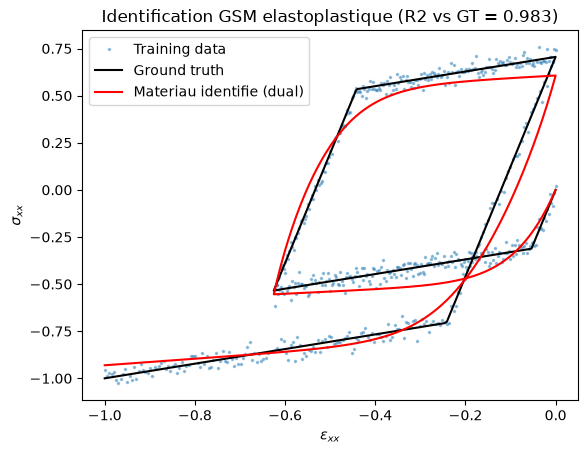

In [ ]:
sig_pred_dual = compute_evolution(trained_material_gsm_dual, eps_xx)

sig_pred_dual_np = np.asarray(sig_pred_dual)
sig_xx_np = np.asarray(sig_xx)
sigxx_exp_np = np.asarray(sigxx_exp)

r2_gt_dual = r2_score(sig_xx_np, sig_pred_dual_np)
r2_train_dual = r2_score(sigxx_exp_np, sig_pred_dual_np)
mse_gt_dual = float(np.mean((sig_pred_dual_np - sig_xx_np) ** 2))

print(f"R2 (vs ground truth propre) = {r2_gt_dual:.4f} ")
print(f"R2 (vs donnees bruitees)    = {r2_train_dual:.4f}")

plt.figure()
plt.plot(epsxx_exp, sigxx_exp, ".", ms=3, alpha=0.4, label="Training data")
plt.plot(eps_xx, sig_xx, "-k", label="Ground truth")
plt.plot(eps_xx, sig_pred_dual, "-r", label="Materiau identifie (dual)")
plt.xlabel(r"$\epsilon_{xx}$"); plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.title(f"Identification GSM elastoplastique (R2 vs GT = {r2_gt_dual:.3f})")
plt.show()

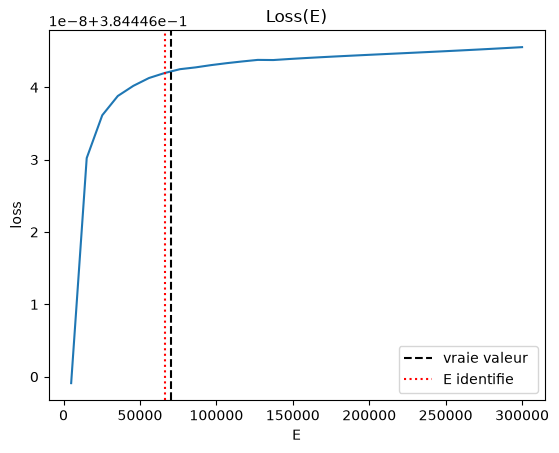

In [ ]:
E_values = jnp.linspace(5000/E_max, 300e3/E_max, 30)

def loss_for_E(E_val, trained_material_gsm_dual):
    mat = trained_material_gsm_dual
    mat = eqx.tree_at(lambda m: m.free_energy.elasticity.E, mat, E_val)
    params_, static_ = eqx.partition(mat, eqx.is_array)
    loss_val, _ = total_loss(params_, (static_, eps_xx, sigxx_exp, gamma1, gamma2))
    return loss_val

losses_E = [float(loss_for_E(E, trained_material_gsm_dual)) for E in E_values]  # params_dual = etat final entraine

plt.figure()
plt.plot(E_values * E_max, losses_E)
plt.axvline(70000, color="k", linestyle="--", label="vraie valeur ")
plt.axvline(float(trained_material_gsm_dual.free_energy.elasticity.E) * E_max,
            color="r", linestyle=":", label="E identifie ")
plt.xlabel("E"); plt.ylabel("loss"); plt.legend()
plt.title("Loss(E)")
plt.show()

## VIII. Simulation complète

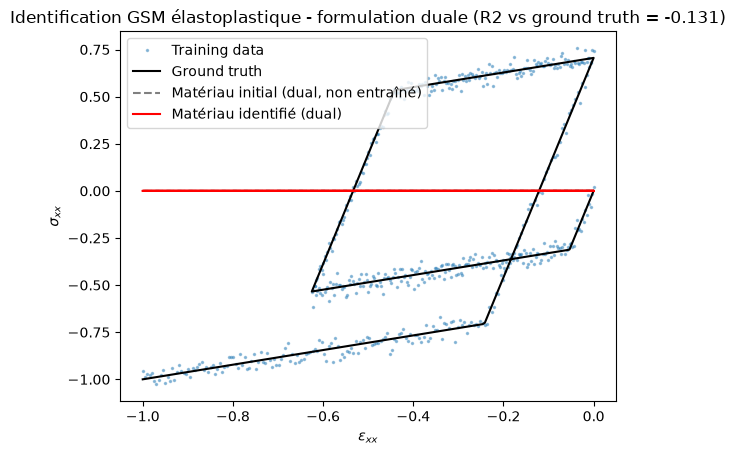

R2 final (vs ground truth) = -0.1309


In [ ]:
# Simulation avec le materiau identifie
sig_pred = compute_evolution(trained_material_gsm_dual, eps_xx)

r2_final = r2_score(np.asarray(sig_xx), np.asarray(sig_pred))

plt.figure()
plt.plot(epsxx_exp, sigxx_exp, ".", ms=3, alpha=0.4, label="Training data")
plt.plot(eps_xx, sig_xx, "-k", label="Ground truth")
plt.plot(eps_xx, sig_init, "--", color="gray", label="Matériau initial (dual, non entraîné)")
plt.plot(eps_xx, sig_pred, "-r", label="Matériau identifié (dual)")
plt.xlabel(r"$\epsilon_{xx}$")
plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.title(f"Identification GSM élastoplastique - formulation duale (R2 vs ground truth = {r2_final:.3f})")
plt.show()

print(f"R2 final (vs ground truth) = {r2_final:.4f}")